In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
from PIL import Image
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchsummary import summary

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print('Libraries imported successfully')

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Libraries imported successfully


In [6]:
# Load preprocessed data
print('Loading preprocessed data...')

DATA_PATH = '/kaggle/input/brain-tumor-mri-preprocess-sets/'

# Load train set (augmented)
train_images = np.load(os.path.join(DATA_PATH, 'preprocessed_train_images.npy'), mmap_mode='r')
train_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_train_labels.npy'))

# Load validation set (original, not augmented)
val_images = np.load(os.path.join(DATA_PATH, 'preprocessed_val_images.npy'), mmap_mode='r')
val_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_val_labels.npy'))

# Load test set (original, not augmented)
test_images = np.load(os.path.join(DATA_PATH, 'preprocessed_test_images.npy'), mmap_mode='r')
test_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_test_labels.npy'))

# Load class names
label_classes = np.load(os.path.join(DATA_PATH, 'label_classes.npy'))

print('Preprocessed data loaded successfully!')
print(f'\nTrain set: {len(train_images)} images, shape: {train_images[0].shape}')
print(f'Validation set: {len(val_images)} images, shape: {val_images[0].shape}')
print(f'Test set: {len(test_images)} images, shape: {test_images[0].shape}')

# Check class distribution
print('\nClass distribution:')
print(f'Classes: {label_classes}')

Loading preprocessed data...
Preprocessed data loaded successfully!

Train set: 22845 images, shape: (256, 256, 3)
Validation set: 1143 images, shape: (256, 256, 3)
Test set: 1311 images, shape: (256, 256, 3)

Class distribution:
Classes: ['glioma_tumor' 'meningioma_tumor' 'no_tumor' 'pituitary_tumor']


In [7]:
# Use actual labels from data:
label_classes = np.unique(np.concatenate([train_labels, val_labels, test_labels]))
label_classes = np.sort(label_classes)

print(f'Using actual classes: {label_classes}')

label_encoder = LabelEncoder()
label_encoder.classes_ = label_classes

Using actual classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


In [ ]:
# Encode labels (they're already strings from preprocessing)
train_labels_encoded = label_encoder.transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Create label mapping for reference
label_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
print('\nLabel mapping:')
for idx, class_name in label_mapping.items():
    print(f'{idx}: {class_name}')

# Store class names for later use
class_names = label_encoder.classes_
num_classes = len(class_names)
print(f'\nNumber of classes: {num_classes}')


Label mapping:
0: glioma
1: meningioma
2: notumor
3: pituitary

Number of classes: 4


In [9]:
# Verify data distribution (already split in preprocessing)
print('\nTraining set distribution:')
unique, counts = np.unique(train_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')

print('\nValidation set distribution:')
unique, counts = np.unique(val_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')

print('\nTest set distribution:')
unique, counts = np.unique(test_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')


Training set distribution:
glioma: 5285 images
meningioma: 5355 images
notumor: 6380 images
pituitary: 5825 images

Validation set distribution:
glioma: 264 images
meningioma: 268 images
notumor: 319 images
pituitary: 292 images

Test set distribution:
glioma: 300 images
meningioma: 306 images
notumor: 405 images
pituitary: 300 images


In [10]:
class BrainTumorDataset(Dataset):
    """
    Custom dataset that loads images on-the-fly from memory-mapped array
    Images are already preprocessed to 256x256 with gamma correction
    Only needs to resize if model requires different input size
    """
    def __init__(self, images_mmap, labels, input_size=256):
        self.images_mmap = images_mmap
        self.labels = labels
        self.input_size = input_size
        self.needs_resize = (input_size != 256)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Load image from memory-mapped array
        image = self.images_mmap[idx].copy()
        label = self.labels[idx]
        
        # Images are already gamma corrected and in range 0-255
        # Normalize to 0-1
        image = image.astype(np.float32) / 255.0
        
        # Convert BGR to RGB
        image = image[:, :, [2, 1, 0]]
        
        # Resize only if model requires different size
        if self.needs_resize:
            image_pil = Image.fromarray((image * 255).astype(np.uint8))
            image_pil = image_pil.resize((self.input_size, self.input_size), Image.LANCZOS)
            image = np.array(image_pil).astype(np.float32) / 255.0
        
        # Convert to tensor and permute to (C, H, W)
        image_tensor = torch.from_numpy(image).permute(2, 0, 1)
        
        # Apply ImageNet normalization
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_tensor = (image_tensor - mean) / std
        
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        return image_tensor, label_tensor

print('Custom Dataset class defined')

Custom Dataset class defined


In [ ]:
# Model Configuration
INPUT_SIZE = 224
BATCH_SIZE = 32
EMBED_DIM = 144
NUM_HEADS = 12
FF_DIM = 288
NUM_TRANSFORMER_BLOCKS = 2
PATCH_SIZE = 16
DROPOUT = 0.2  

print(f'Configuration:')
print(f'Input Size: {INPUT_SIZE}x{INPUT_SIZE}')
print(f'Batch Size: {BATCH_SIZE}')
print(f'Embedding Dimension: {EMBED_DIM}')
print(f'Transformer Blocks: {NUM_TRANSFORMER_BLOCKS}')
print(f'Dropout: {DROPOUT}')

Configuration:
Input Size: 224x224
Batch Size: 32
Embedding Dimension: 144
Transformer Blocks: 2
Dropout: 0.2


In [14]:
print(f'Creating datasets with input size: {INPUT_SIZE}x{INPUT_SIZE}...')

# Create datasets
train_dataset = BrainTumorDataset(train_images, train_labels_encoded, input_size=INPUT_SIZE)
val_dataset = BrainTumorDataset(val_images, val_labels_encoded, input_size=INPUT_SIZE)
test_dataset = BrainTumorDataset(test_images, test_labels_encoded, input_size=INPUT_SIZE)

print('Datasets created successfully')
print(f'Train dataset: {len(train_dataset)} images')
print(f'Val dataset: {len(val_dataset)} images')
print(f'Test dataset: {len(test_dataset)} images')

Creating datasets with input size: 224x224...
Datasets created successfully
Train dataset: 22845 images
Val dataset: 1143 images
Test dataset: 1311 images


In [15]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=2, pin_memory=True)

print('DataLoaders created')
print(f'Batch size: {BATCH_SIZE}')
print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

# Test loading one batch
print('\nTesting data loading...')
test_batch = next(iter(train_loader))
print(f'Batch images shape: {test_batch[0].shape}')
print(f'Batch labels shape: {test_batch[1].shape}')
print('Data loading test successful!')

DataLoaders created
Batch size: 32
Training batches: 714
Validation batches: 36
Test batches: 41

Testing data loading...
Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Data loading test successful!


In [16]:
class PatchEmbedding(nn.Module):
    """
    Converts CNN feature maps into patches for Vision Transformer
    Like cutting a cricket field into zones for analysis
    """
    def __init__(self, in_channels, embed_dim, patch_size=16):
        super(PatchEmbedding, self).__init__()
        # Use convolution to create patches
        self.patch_embed = nn.Conv2d(
            in_channels, 
            embed_dim, 
            kernel_size=patch_size, 
            stride=patch_size
        )
        self.norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        # x: (B, C, H, W) from MobileNet
        x = self.patch_embed(x)  # (B, embed_dim, H/patch_size, W/patch_size)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        x = self.norm(x)
        return x

print('Patch Embedding module defined')

Patch Embedding module defined


In [17]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head attention mechanism from Vision Transformer
    Like multiple scouts analyzing different aspects of a player
    """
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        assert self.head_dim * num_heads == embed_dim, "embed_dim must be divisible by num_heads"
        
        # Query, Key, Value projections
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        
    def forward(self, x):
        B, N, C = x.shape
        
        # Generate Q, K, V
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # Each: (B, num_heads, N, head_dim)
        
        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        
        # Apply attention to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        
        return x

print('Multi-Head Self-Attention module defined')

Multi-Head Self-Attention module defined


In [18]:
class TransformerEncoderBlock(nn.Module):
    """
    Single transformer encoder block with attention and feed-forward
    Like one round of team analysis - first attention, then deeper processing
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        
        # Multi-head attention
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        
        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        
    def forward(self, x):
        # Attention with residual connection
        attn_output = self.attention(x)
        x = x + self.dropout1(attn_output)
        x = self.norm1(x)
        
        # Feed-forward with residual connection
        ffn_output = self.ffn(x)
        x = x + ffn_output
        x = self.norm2(x)
        
        return x

print('Transformer Encoder Block defined')

Transformer Encoder Block defined


In [ ]:
class MobileNetViT(nn.Module):
    """
    Hybrid MobileNetV2 + Vision Transformer for Brain Tumor Classification
    
    Architecture (EXACT same as BrainTumorViT, just different CNN backbone):
    1. MobileNetV2 (TorchVision) extracts CNN features
    2. Features are tokenized (patch embedding)
    3. Features split into q1 and q2:
       - q1: Goes through MobileNet again (local features)
       - q2: Goes through Transformer (global features)
    4. Both streams fused
    5. Classification head
    """
    def __init__(self, num_classes, embed_dim=144, num_heads=12, 
                 ff_dim=288, num_transformer_blocks=2, dropout=0.1):
        super(MobileNetViT, self).__init__()
        
        # MobileNetV2 backbone (pretrained on ImageNet) - using TorchVision
        mobilenet_full = models.mobilenet_v2(pretrained=True)
        
        # Extract only the feature extractor (remove classifier)
        self.mobilenet = mobilenet_full.features
        
        # Add adaptive pooling to get consistent 7x7 output
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))
        
        # Get MobileNetV2 output channels (1280 for MobileNetV2)
        mobilenet_out_channels = 1280
        
        # Patch embedding to convert CNN features to tokens
        self.patch_embedding = PatchEmbedding(
            in_channels=mobilenet_out_channels,
            embed_dim=embed_dim,
            patch_size=1  
        )
        
        # Positional embedding
        num_patches = 49  # 7x7
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, embed_dim))
        
        # Transformer encoder blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_transformer_blocks)
        ])
        
        # Additional MobileNet processing for q1 stream
        self.local_conv = nn.Sequential(
            nn.Conv2d(mobilenet_out_channels, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        
        # Fusion and classification head
        self.fusion = nn.Linear(embed_dim * 2, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
        # Classification head with 2 dense layers
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # Step 1: Extract features using MobileNetV2
        # Input: (B, 3, 224, 224)
        mobilenet_features = self.mobilenet(x)  # (B, 1280, H, W)
        
        # Ensure output is 7x7
        mobilenet_features = self.adaptive_pool(mobilenet_features)  # (B, 1280, 7, 7)
        
        # Step 2: Tokenization (patch embedding)
        # Output: (B, 49, 144)
        tokens = self.patch_embedding(mobilenet_features)
        
        # Add positional embedding
        tokens = tokens + self.pos_embedding
        
        # Step 3: Dual-Block Split
        # Split tokens into two groups: q1 for local, q2 for global
        # Split along the token dimension (NOT embedding dimension)
        num_tokens = tokens.shape[1]  # 49
        split_point = num_tokens // 2  # 24
        
        # q1: First half of tokens → Local processing through CNN
        # q2: Second half of tokens → Global processing through Transformer
        q1_tokens = tokens[:, :split_point, :]  # (B, 24, 144)
        q2_tokens = tokens[:, split_point:, :]  # (B, 25, 144)
        
        # Step 4a: Process q2 through transformer (global features)
        for transformer_block in self.transformer_blocks:
            q2_tokens = transformer_block(q2_tokens)
        
        # Global pooling for transformer output
        global_features = q2_tokens.mean(dim=1)  # (B, 144)
        
        # Step 4b: Process q1 through additional CNN layers (local features)
        # Pool q1 back to spatial features for CNN processing
        local_features = self.local_conv(mobilenet_features)  # (B, 144, 1, 1)
        local_features = local_features.flatten(1)  # (B, 144)
        
        # Step 5: Fuse local and global features
        fused_features = torch.cat([local_features, global_features], dim=1)  # (B, 288)
        fused_features = self.fusion(fused_features)  # (B, 144)
        fused_features = self.dropout(fused_features)
        
        # Step 6: Classification
        output = self.classifier(fused_features)
        
        return output

print('MobileNetViT model defined (using TorchVision)')

MobileNetViT model defined (using TorchVision)


In [ ]:
# Recreate model with increased dropout
print('\nCreating MobileNetViT model with updated dropout...')
model = MobileNetViT(
    num_classes=num_classes,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
    dropout=DROPOUT 
)

model = model.to(device)
print('Model created and moved to device')

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nModel Statistics:')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model size: ~{total_params * 4 / (1024**2):.2f} MB')


Creating MobileNetViT model with updated dropout...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 182MB/s]

Model created and moved to device

Model Statistics:
Total parameters: 2,986,532
Trainable parameters: 2,986,532
Model size: ~11.39 MB


In [ ]:
# Phase 1: Frozen backbone training
PHASE1_EPOCHS = 20
PHASE1_LR_START = 0.0
PHASE1_LR_TARGET = 0.001 
WARMUP_EPOCHS = 3
PHASE1_PATIENCE = 7

# Phase 2: Full fine-tuning
PHASE2_EPOCHS = 30
PHASE2_LR = 0.0001 
PHASE2_PATIENCE = 10

# Regularization
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.1  
MAX_GRAD_NORM = 1.0  

print('Training configuration:')
print(f'Phase 1: {PHASE1_EPOCHS} epochs, LR warmup {PHASE1_LR_START} to {PHASE1_LR_TARGET}')
print(f'Warmup epochs: {WARMUP_EPOCHS}')
print(f'Phase 1 patience: {PHASE1_PATIENCE}')
print(f'Phase 2: {PHASE2_EPOCHS} epochs, LR {PHASE2_LR}')
print(f'Phase 2 patience: {PHASE2_PATIENCE}')
print(f'Weight decay: {WEIGHT_DECAY}')
print(f'Label smoothing: {LABEL_SMOOTHING}')
print(f'Gradient clipping: {MAX_GRAD_NORM}')

Training configuration:
Phase 1: 20 epochs, LR warmup 0.0 to 0.001
Warmup epochs: 3
Phase 1 patience: 7
Phase 2: 30 epochs, LR 0.0001
Phase 2 patience: 10
Weight decay: 0.01
Label smoothing: 0.1
Gradient clipping: 1.0


In [ ]:
# Added label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f'Loss function: CrossEntropyLoss with label smoothing {LABEL_SMOOTHING}')

Loss function: CrossEntropyLoss with label smoothing 0.1


In [ ]:
# Added gradient clipping
def train_epoch(model, train_loader, criterion, optimizer, device, max_grad_norm=1.0):
    """Train for one epoch with gradient clipping"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        # NEW: Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print('Training functions defined with gradient clipping')

Training functions defined with gradient clipping


In [ ]:
# Phase 1 training with frozen backbone and warmup
print('\nPhase 1: Training with frozen backbone and warmup')
print(f'Warmup: Epochs 1-{WARMUP_EPOCHS} (LR: {PHASE1_LR_START} to {PHASE1_LR_TARGET})')
print(f'Training: Epochs {WARMUP_EPOCHS+1}-{PHASE1_EPOCHS} (LR: {PHASE1_LR_TARGET})')

# Freeze MobileNetV2 backbone
print('\nFreezing MobileNetV2 backbone...')
for param in model.mobilenet.parameters():
    param.requires_grad = False

phase1_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters in Phase 1: {phase1_trainable:,}')

# Optimizer for Phase 1
optimizer_phase1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR_START,
    weight_decay=WEIGHT_DECAY
)

# Training history for Phase 1
phase1_history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_loss_phase1 = float('inf')
patience_counter_phase1 = 0
best_model_wts_phase1 = None

print('\nStarting Phase 1 training...')

for epoch in range(PHASE1_EPOCHS):
    # Warmup learning rate schedule
    if epoch < WARMUP_EPOCHS:
        current_lr = PHASE1_LR_START + (PHASE1_LR_TARGET - PHASE1_LR_START) * ((epoch + 1) / WARMUP_EPOCHS)
        phase_name = "Warmup"
    else:
        current_lr = PHASE1_LR_TARGET
        phase_name = "Training"
    
    # Set learning rate
    for param_group in optimizer_phase1.param_groups:
        param_group['lr'] = current_lr
    
    # Train and validate
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer_phase1, device, MAX_GRAD_NORM)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Store history
    phase1_history['epoch'].append(epoch + 1)
    phase1_history['train_loss'].append(train_loss)
    phase1_history['train_acc'].append(train_acc)
    phase1_history['val_loss'].append(val_loss)
    phase1_history['val_acc'].append(val_acc)
    phase1_history['lr'].append(current_lr)
    
    # Print progress
    print(f'\nPhase 1 ({phase_name}) - Epoch {epoch+1}/{PHASE1_EPOCHS}')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'LR: {current_lr:.6f}')
    
    # Early stopping only after warmup
    if epoch >= WARMUP_EPOCHS:
        if val_loss < best_val_loss_phase1:
            best_val_loss_phase1 = val_loss
            patience_counter_phase1 = 0
            best_model_wts_phase1 = copy.deepcopy(model.state_dict())
            print('Validation loss improved - saving model')
        else:
            patience_counter_phase1 += 1
            print(f'No improvement - patience: {patience_counter_phase1}/{PHASE1_PATIENCE}')
        
        if patience_counter_phase1 >= PHASE1_PATIENCE:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

# Load best Phase 1 model
if best_model_wts_phase1 is not None:
    model.load_state_dict(best_model_wts_phase1)
    print(f'\nLoaded best Phase 1 model (Val Loss: {best_val_loss_phase1:.4f})')

print('Phase 1 training completed')


Phase 1: Training with frozen backbone and warmup
Warmup: Epochs 1-3 (LR: 0.0 to 0.001)
Training: Epochs 4-20 (LR: 0.001)

Freezing MobileNetV2 backbone...
Trainable parameters in Phase 1: 762,660

Starting Phase 1 training...

Phase 1 (Warmup) - Epoch 1/20
Train Loss: 0.6307, Train Acc: 0.8581
Val Loss: 0.5413, Val Acc: 0.9073
LR: 0.000333

Phase 1 (Warmup) - Epoch 2/20
Train Loss: 0.5345, Train Acc: 0.9143
Val Loss: 0.5231, Val Acc: 0.9108
LR: 0.000667

Phase 1 (Warmup) - Epoch 3/20
Train Loss: 0.5047, Train Acc: 0.9339
Val Loss: 0.4916, Val Acc: 0.9309
LR: 0.001000

Phase 1 (Training) - Epoch 4/20
Train Loss: 0.4739, Train Acc: 0.9492
Val Loss: 0.4814, Val Acc: 0.9370
LR: 0.001000
Validation loss improved - saving model

Phase 1 (Training) - Epoch 5/20
Train Loss: 0.4558, Train Acc: 0.9598
Val Loss: 0.4531, Val Acc: 0.9554
LR: 0.001000
Validation loss improved - saving model

Phase 1 (Training) - Epoch 6/20
Train Loss: 0.4399, Train Acc: 0.9666
Val Loss: 0.5114, Val Acc: 0.9335
LR:

In [ ]:
# Phase 2 training with full fine-tuning
print('\n\nPhase 2: Fine-tuning entire network')
print(f'Epochs: {PHASE2_EPOCHS}, Learning Rate: {PHASE2_LR}')

# Unfreeze all parameters
print('\nUnfreezing all parameters...')
for param in model.parameters():
    param.requires_grad = True

phase2_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters in Phase 2: {phase2_trainable:,}')

# Optimizer for Phase 2
optimizer_phase2 = optim.AdamW(
    model.parameters(),
    lr=PHASE2_LR,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler for Phase 2
scheduler_phase2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2,
    mode='min',
    factor=0.5,
    patience=5
)

# Training history for Phase 2
phase2_history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_loss_phase2 = float('inf')
patience_counter_phase2 = 0
best_model_wts_phase2 = None

print('\nStarting Phase 2 training...')

for epoch in range(PHASE2_EPOCHS):
    current_lr = optimizer_phase2.param_groups[0]['lr']
    
    # Train and validate
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer_phase2, device, MAX_GRAD_NORM)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Step scheduler
    scheduler_phase2.step(val_loss)
    
    # Store history
    phase2_history['epoch'].append(epoch + 1)
    phase2_history['train_loss'].append(train_loss)
    phase2_history['train_acc'].append(train_acc)
    phase2_history['val_loss'].append(val_loss)
    phase2_history['val_acc'].append(val_acc)
    phase2_history['lr'].append(current_lr)
    
    # Print progress
    print(f'\nPhase 2 - Epoch {epoch+1}/{PHASE2_EPOCHS} (Total: {PHASE1_EPOCHS + epoch+1})')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'LR: {current_lr:.6f}')
    
    # Check if LR was reduced
    new_lr = optimizer_phase2.param_groups[0]['lr']
    if new_lr < current_lr:
        print(f'Learning rate reduced from {current_lr:.6f} to {new_lr:.6f}')
    
    # Early stopping
    if val_loss < best_val_loss_phase2:
        best_val_loss_phase2 = val_loss
        patience_counter_phase2 = 0
        best_model_wts_phase2 = copy.deepcopy(model.state_dict())
        print('Validation loss improved - saving model')
    else:
        patience_counter_phase2 += 1
        print(f'No improvement - patience: {patience_counter_phase2}/{PHASE2_PATIENCE}')
    
    if patience_counter_phase2 >= PHASE2_PATIENCE:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

# Load best Phase 2 model
if best_model_wts_phase2 is not None:
    model.load_state_dict(best_model_wts_phase2)
    print(f'\nLoaded best Phase 2 model (Val Loss: {best_val_loss_phase2:.4f})')

print('Phase 2 training completed')
print('\nTraining finished!')



Phase 2: Fine-tuning entire network
Epochs: 30, Learning Rate: 0.0001

Unfreezing all parameters...
Trainable parameters in Phase 2: 2,986,532

Starting Phase 2 training...

Phase 2 - Epoch 1/30 (Total: 21)
Train Loss: 0.4149, Train Acc: 0.9764
Val Loss: 0.4364, Val Acc: 0.9615
LR: 0.000100
Validation loss improved - saving model

Phase 2 - Epoch 2/30 (Total: 22)
Train Loss: 0.3834, Train Acc: 0.9911
Val Loss: 0.3995, Val Acc: 0.9781
LR: 0.000100
Validation loss improved - saving model

Phase 2 - Epoch 3/30 (Total: 23)
Train Loss: 0.3726, Train Acc: 0.9953
Val Loss: 0.3863, Val Acc: 0.9808
LR: 0.000100
Validation loss improved - saving model

Phase 2 - Epoch 4/30 (Total: 24)
Train Loss: 0.3685, Train Acc: 0.9964
Val Loss: 0.4093, Val Acc: 0.9668
LR: 0.000100
No improvement - patience: 1/10

Phase 2 - Epoch 5/30 (Total: 25)
Train Loss: 0.3658, Train Acc: 0.9973
Val Loss: 0.3779, Val Acc: 0.9878
LR: 0.000100
Validation loss improved - saving model

Phase 2 - Epoch 6/30 (Total: 26)
Trai

In [ ]:
# Combine both phases for plotting
print('\nCombining training history from both phases...')

combined_history = {
    'epoch': phase1_history['epoch'] + [e + PHASE1_EPOCHS for e in phase2_history['epoch']],
    'train_loss': phase1_history['train_loss'] + phase2_history['train_loss'],
    'train_acc': phase1_history['train_acc'] + phase2_history['train_acc'],
    'val_loss': phase1_history['val_loss'] + phase2_history['val_loss'],
    'val_acc': phase1_history['val_acc'] + phase2_history['val_acc'],
    'lr': phase1_history['lr'] + phase2_history['lr']
}

history_df = pd.DataFrame(combined_history)

print(f'Total epochs trained: {len(combined_history["epoch"])}')
print(f'Best validation accuracy: {max(combined_history["val_acc"]):.4f}')
print(f'Final validation accuracy: {combined_history["val_acc"][-1]:.4f}')


Combining training history from both phases...
Total epochs trained: 39
Best validation accuracy: 0.9913
Final validation accuracy: 0.9816


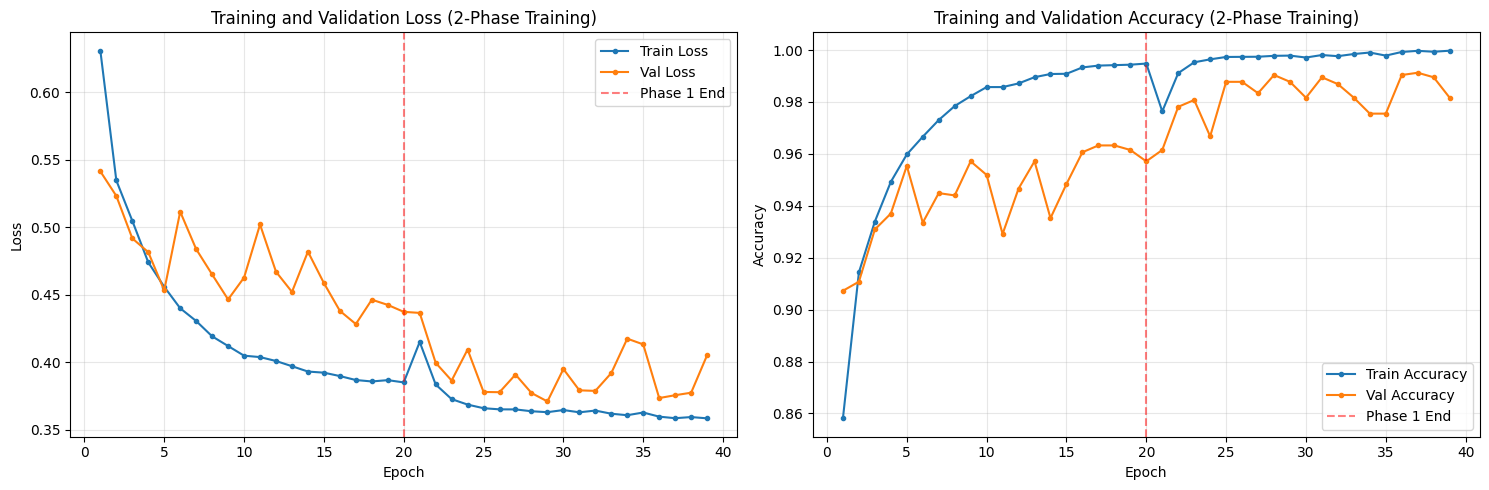

Training history plotted and saved


In [32]:
# Create training history plots with phase separation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='o', markersize=3)
axes[0].axvline(x=PHASE1_EPOCHS, color='red', linestyle='--', alpha=0.5, label='Phase 1 End')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss (2-Phase Training)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Train Accuracy', marker='o', markersize=3)
axes[1].plot(history_df['epoch'], history_df['val_acc'], label='Val Accuracy', marker='o', markersize=3)
axes[1].axvline(x=PHASE1_EPOCHS, color='red', linestyle='--', alpha=0.5, label='Phase 1 End')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy (2-Phase Training)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mobilenetvit_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print('Training history plotted and saved')

In [33]:
def evaluate_model(model, test_loader, device):
    """
    Evaluate model on test set and return predictions and labels
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Get predictions on test set
print('Evaluating model on test set...')
test_preds, test_labels_array, test_probs = evaluate_model(model, test_loader, device)

# Calculate metrics
test_accuracy = accuracy_score(test_labels_array, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels_array, test_preds, average='weighted')

print('Test Set Results:')
print(f'Accuracy: {test_accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print()

# Per-class metrics
print('Per-Class Metrics:')
class_report = classification_report(test_labels_array, test_preds, target_names=class_names, digits=4)
print(class_report)

Evaluating model on test set...
Test Set Results:
Accuracy: 0.9916
Precision: 0.9916
Recall: 0.9916
F1-Score: 0.9916

Per-Class Metrics:
              precision    recall  f1-score   support

      glioma     0.9900    0.9900    0.9900       300
  meningioma     0.9869    0.9837    0.9853       306
     notumor     0.9951    0.9951    0.9951       405
   pituitary     0.9934    0.9967    0.9950       300

    accuracy                         0.9916      1311
   macro avg     0.9913    0.9913    0.9913      1311
weighted avg     0.9916    0.9916    0.9916      1311



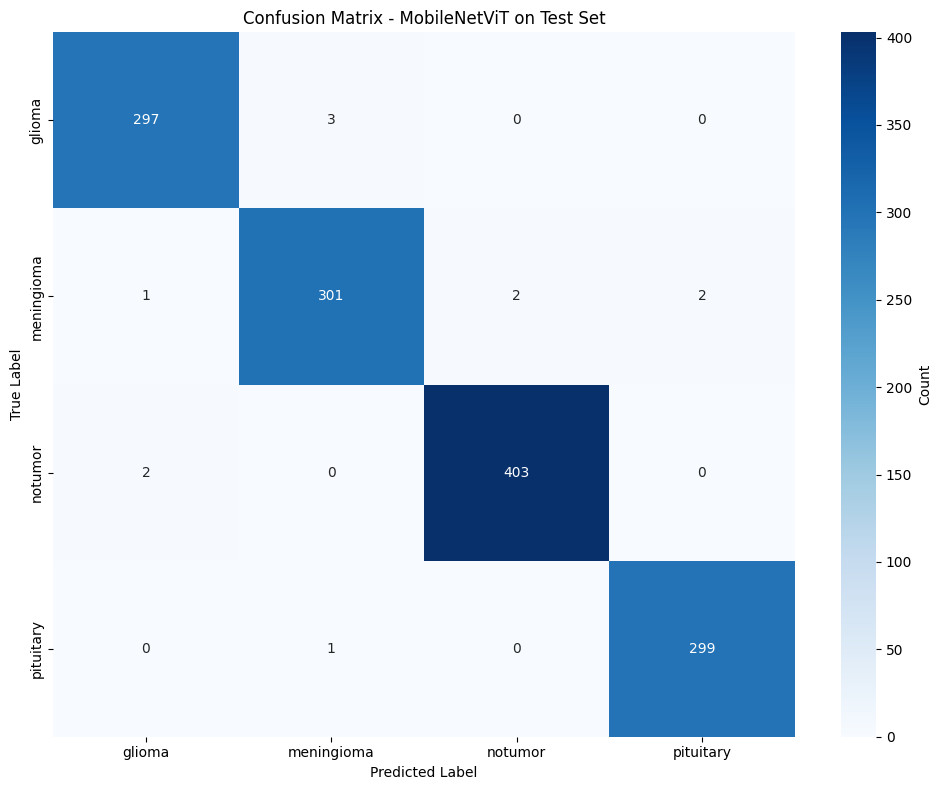

Per-Class Accuracy:
glioma: 0.9900
meningioma: 0.9837
notumor: 0.9951
pituitary: 0.9967


In [34]:
# Calculate confusion matrix
cm = confusion_matrix(test_labels_array, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MobileNetViT on Test Set')
plt.tight_layout()
plt.savefig('mobilenetvit_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print('Per-Class Accuracy:')
for i, class_name in enumerate(class_names):
    print(f'{class_name}: {per_class_acc[i]:.4f}')

In [35]:
pip install thop

Note: you may need to restart the kernel to use updated packages.


In [36]:
from thop import profile

def calculate_efficiency_metrics(model, device, input_size=(1, 3, 224, 224)):
    """
    Calculate comprehensive efficiency metrics
    """
    model.eval()
    
    # Total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Model size in MB
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    # FLOPs calculation
    dummy_input = torch.randn(input_size).to(device)
    flops, params_thop = profile(model, inputs=(dummy_input,), verbose=False)
    flops_gflops = flops / 1e9
    
    # Inference time and FPS
    num_warmup = 10
    num_iterations = 100
    
    # Warmup
    with torch.no_grad():
        for _ in range(num_warmup):
            _ = model(dummy_input)
    
    # Synchronize GPU
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    # Measure inference time
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    end_time = time.time()
    
    avg_time_per_image = ((end_time - start_time) / num_iterations) * 1000
    fps = 1000 / avg_time_per_image
    
    # GPU memory usage
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        
        with torch.no_grad():
            _ = model(dummy_input)
        
        gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        gpu_memory_mb = 0
    
    metrics = {
        'Total Parameters': total_params,
        'Trainable Parameters': trainable_params,
        'Model Size (MB)': model_size_mb,
        'FLOPs (GFLOPs)': flops_gflops,
        'Inference Time (ms)': avg_time_per_image,
        'FPS': fps,
        'GPU Memory (MB)': gpu_memory_mb
    }
    
    return metrics

# Calculate efficiency metrics
print('Calculating efficiency metrics...')
efficiency_metrics = calculate_efficiency_metrics(model, device, input_size=(1, 3, INPUT_SIZE, INPUT_SIZE))

print('\nEfficiency Metrics:')
print(f"Total Parameters: {efficiency_metrics['Total Parameters']:,}")
print(f"Trainable Parameters: {efficiency_metrics['Trainable Parameters']:,}")
print(f"Model Size: {efficiency_metrics['Model Size (MB)']:.2f} MB")
print(f"FLOPs: {efficiency_metrics['FLOPs (GFLOPs)']:.2f} GFLOPs")
print(f"Inference Time: {efficiency_metrics['Inference Time (ms)']:.2f} ms per image")
print(f"FPS: {efficiency_metrics['FPS']:.2f}")
print(f"GPU Memory Usage: {efficiency_metrics['GPU Memory (MB)']:.2f} MB")

Calculating efficiency metrics...

Efficiency Metrics:
Total Parameters: 2,986,532
Trainable Parameters: 2,986,532
Model Size: 11.52 MB
FLOPs: 0.35 GFLOPs
Inference Time: 6.11 ms per image
FPS: 163.73
GPU Memory Usage: 103.27 MB


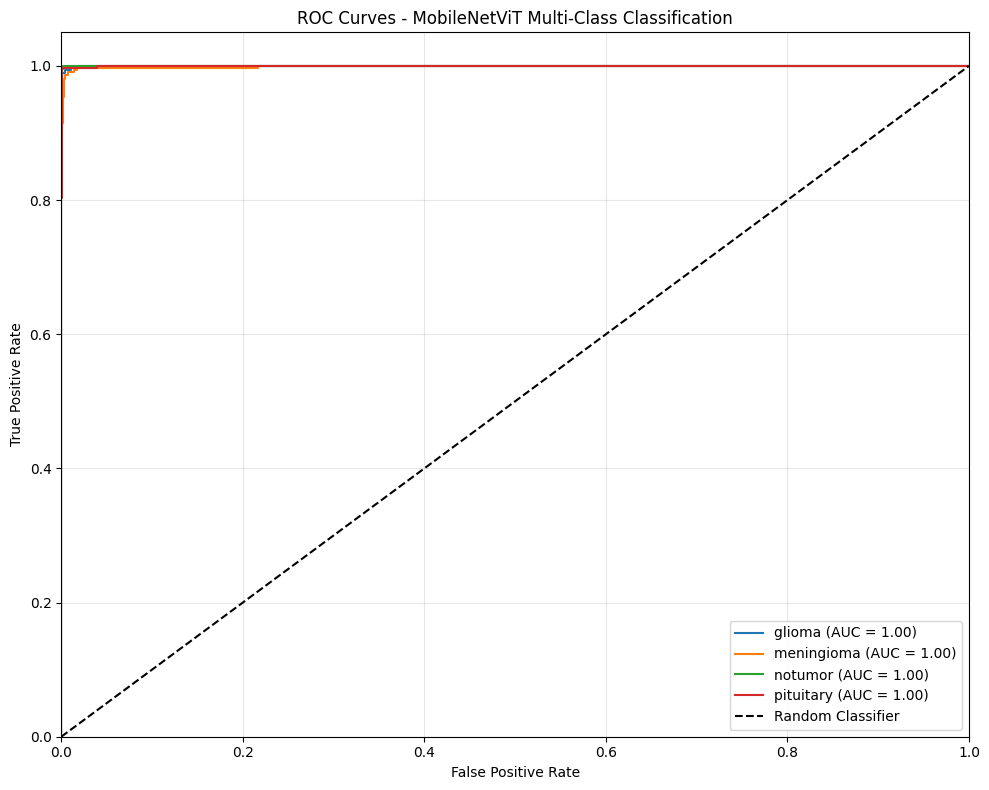

ROC curves plotted and saved


In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(test_labels_array, classes=range(num_classes))

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - MobileNetViT Multi-Class Classification')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mobilenetvit_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('ROC curves plotted and saved')

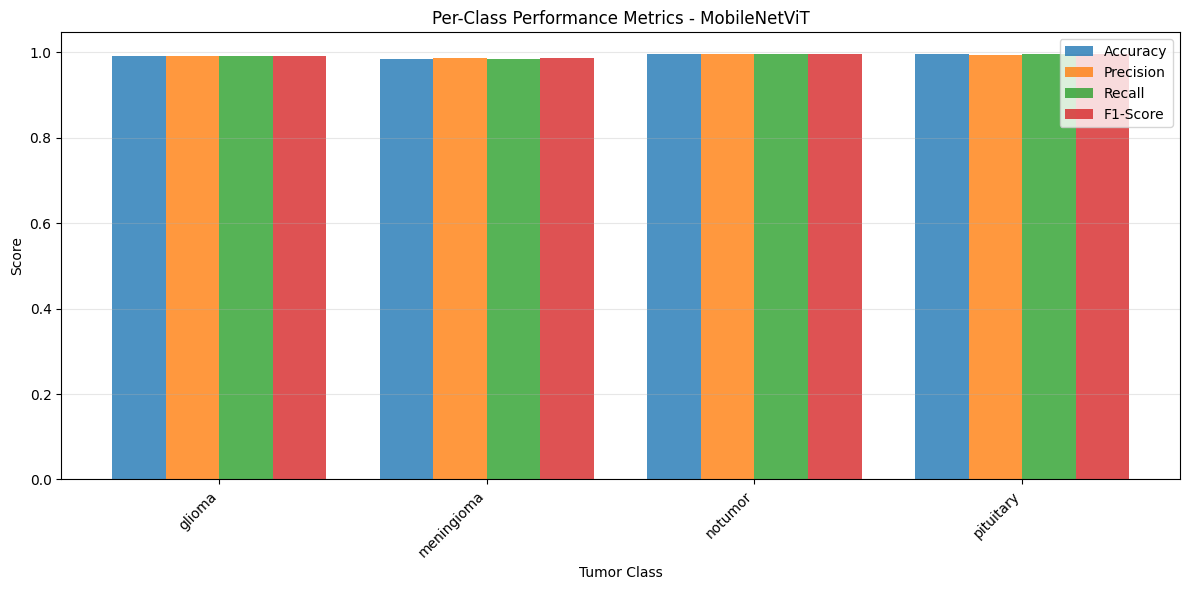

Per-class performance visualization saved


In [38]:
# Create per-class performance bar chart
per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(
    test_labels_array, test_preds, average=None
)

# Create DataFrame for easier plotting
performance_data = pd.DataFrame({
    'Class': class_names,
    'Accuracy': per_class_acc,
    'Precision': per_class_precision,
    'Recall': per_class_recall,
    'F1-Score': per_class_f1
})

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.2

ax.bar(x - 1.5*width, performance_data['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x - 0.5*width, performance_data['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + 0.5*width, performance_data['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + 1.5*width, performance_data['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Tumor Class')
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics - MobileNetViT')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('mobilenetvit_per_class_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print('Per-class performance visualization saved')

In [ ]:
# Create results dictionary
results = {
    'model_name': 'MobileNetViT',
    'architecture': 'MobileNetV2 + Vision Transformer',
    'input_size': INPUT_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs_trained': len(combined_history['epoch']),  
    'test_accuracy': test_accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'per_class_accuracy': {class_names[i]: per_class_acc[i] for i in range(len(class_names))},
    **efficiency_metrics
}

# Save results to CSV
results_df = pd.DataFrame([results])
results_df.to_csv('mobilenetvit_results.csv', index=False)
print('Results saved to mobilenetvit_results.csv')

# Save training history
history_df.to_csv('mobilenetvit_training_history.csv', index=False)
print('Training history saved to mobilenetvit_training_history.csv')

# Save per-class performance
performance_data.to_csv('mobilenetvit_per_class_performance.csv', index=False)
print('Per-class performance saved to mobilenetvit_per_class_performance.csv')

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer_phase2.state_dict(),  
    'class_names': class_names,
    'label_encoder': label_encoder,
    'results': results,
    'history': combined_history,  
    'config': {
        'input_size': INPUT_SIZE,
        'batch_size': BATCH_SIZE,
        'embed_dim': EMBED_DIM,
        'num_heads': NUM_HEADS,
        'ff_dim': FF_DIM,
        'num_transformer_blocks': NUM_TRANSFORMER_BLOCKS,
        'dropout': DROPOUT 
    }
}, 'mobilenetvit_brain_tumor_model.pth')
print('Model saved to mobilenetvit_brain_tumor_model.pth')

print('\nAll results and model saved successfully')

Results saved to mobilenetvit_results.csv
Training history saved to mobilenetvit_training_history.csv
Per-class performance saved to mobilenetvit_per_class_performance.csv
Model saved to mobilenetvit_brain_tumor_model.pth

All results and model saved successfully


In [ ]:
# Create comprehensive summary table for thesis
summary_data = {
    'Metric': [
        'Architecture',
        'Input Size',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'Total Parameters',
        'Model Size (MB)',
        'FLOPs (GFLOPs)',
        'Inference Time (ms)',
        'FPS',
        'GPU Memory (MB)',
        'Epochs Trained',
        'Best Validation Loss Phase 1', 
        'Best Validation Loss Phase 2'  
    ],
    'Value': [
        'MobileNetV2 + ViT',
        f'{INPUT_SIZE}x{INPUT_SIZE}',
        f'{test_accuracy:.4f}',
        f'{precision:.4f}',
        f'{recall:.4f}',
        f'{f1:.4f}',
        f"{efficiency_metrics['Total Parameters']:,}",
        f"{efficiency_metrics['Model Size (MB)']:.2f}",
        f"{efficiency_metrics['FLOPs (GFLOPs)']:.2f}",
        f"{efficiency_metrics['Inference Time (ms)']:.2f}",
        f"{efficiency_metrics['FPS']:.2f}",
        f"{efficiency_metrics['GPU Memory (MB)']:.2f}",
        f"{len(combined_history['epoch'])}",  
        f"{best_val_loss_phase1:.4f}", 
        f"{best_val_loss_phase2:.4f}"  
    ]
}

summary_df = pd.DataFrame(summary_data)
print('MobileNetViT Summary for Thesis:')
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('mobilenetvit_summary_table.csv', index=False)
print('\nSummary table saved to mobilenetvit_summary_table.csv')

MobileNetViT Summary for Thesis:
                      Metric             Value
                Architecture MobileNetV2 + ViT
                  Input Size           224x224
               Test Accuracy            0.9916
                   Precision            0.9916
                      Recall            0.9916
                    F1-Score            0.9916
            Total Parameters         2,986,532
             Model Size (MB)             11.52
              FLOPs (GFLOPs)              0.35
         Inference Time (ms)              6.11
                         FPS            163.73
             GPU Memory (MB)            103.27
              Epochs Trained                39
Best Validation Loss Phase 1            0.4282
Best Validation Loss Phase 2            0.3708

Summary table saved to mobilenetvit_summary_table.csv
